In [ ]:
import spacy

/usr/local/lib/python3.9/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
nlp = spacy.blank("en")

doc = nlp("Dr. Strange loves pav bhaji of mumbai as it costs only 2$ per plate.")

for token in doc:
    print(token)

Dr.
Strange
loves
pav
bhaji
of
mumbai
as
it
costs
only
2
$
per
plate
.


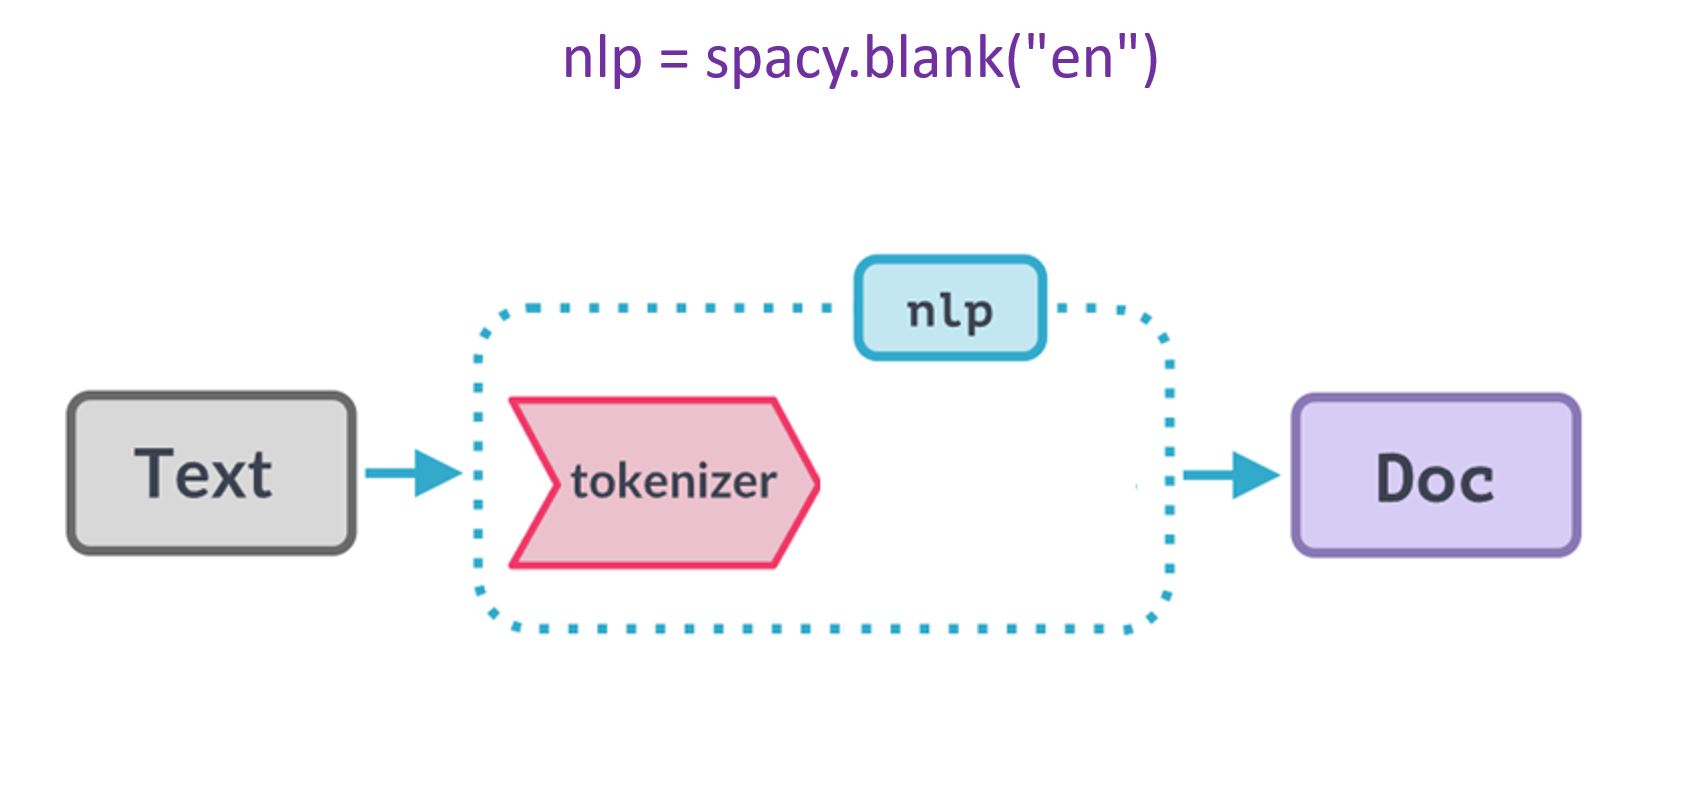

Creating blank language object gives a tokenizer and an empty pipeline. We will look more into language pipelines in next tutorial


Using index to grab tokens

In [ ]:
doc[0]

Dr.

In [ ]:
token = doc[1]
token.text

'Strange'

In [ ]:
dir(token)


['_',
 '__bytes__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__unicode__',
 'ancestors',
 'check_flag',
 'children',
 'cluster',
 'conjuncts',
 'dep',
 'dep_',
 'doc',
 'ent_id',
 'ent_id_',
 'ent_iob',
 'ent_iob_',
 'ent_kb_id',
 'ent_kb_id_',
 'ent_type',
 'ent_type_',
 'get_extension',
 'has_dep',
 'has_extension',
 'has_head',
 'has_morph',
 'has_vector',
 'head',
 'i',
 'idx',
 'iob_strings',
 'is_alpha',
 'is_ancestor',
 'is_ascii',
 'is_bracket',
 'is_currency',
 'is_digit',
 'is_left_punct',
 'is_lower',
 'is_oov',
 'is_punct',
 'is_quote',
 'is_right_punct',
 'is_sent_end',
 'is_sent_start',
 'is_space',
 'is_stop',
 'is_title',
 'is_upper',
 'lang',
 'lang_',
 'le

In [ ]:
type(nlp)

spacy.lang.en.English

In [ ]:
type(doc)

spacy.tokens.doc.Doc

In [ ]:
type(token)

spacy.tokens.token.Token

In [ ]:
nlp.pipe_names

[]

Span object

In [ ]:
span = doc[0:5]
span

Dr. Strange loves pav bhaji

In [ ]:
type(span)

spacy.tokens.span.Span

Token attributes

In [ ]:
doc = nlp("Tony gave two $ to Peter.")

In [ ]:
token0 = doc[0]
token0

Tony

In [ ]:
token0.is_alpha

True

In [ ]:
token0.like_num

False

In [ ]:
token2 = doc[2]
token2

two

In [ ]:
token2.like_num

True

In [ ]:
token3 = doc[3]
token3

$

In [ ]:
token3.like_num

False

In [ ]:
token3.is_currency

True

In [ ]:
for token in doc:
    print(token, "==>", "index: ", token.i, "is_alpha:", token.is_alpha, 
          "is_punct:", token.is_punct, 
          "like_num:", token.like_num,
          "is_currency:", token.is_currency,
         )

Tony ==> index:  0 is_alpha: True is_punct: False like_num: False is_currency: False
gave ==> index:  1 is_alpha: True is_punct: False like_num: False is_currency: False
two ==> index:  2 is_alpha: True is_punct: False like_num: True is_currency: False
$ ==> index:  3 is_alpha: False is_punct: False like_num: False is_currency: True
to ==> index:  4 is_alpha: True is_punct: False like_num: False is_currency: False
Peter ==> index:  5 is_alpha: True is_punct: False like_num: False is_currency: False
. ==> index:  6 is_alpha: False is_punct: True like_num: False is_currency: False


Collecting email ids of students from students information sheet

In [ ]:
with open("students.txt") as f:
    text = f.readlines()
text

FileNotFoundError: ignored

In [ ]:
text = " ".join(text)
text

NameError: ignored

In [ ]:
doc = nlp(text)
emails = []
for token in doc:
    if token.like_email:
        emails.append(token.text)
emails

NameError: ignored

Customizing tokenize

In [ ]:
from spacy.symbols import ORTH

nlp = spacy.blank("en")
doc = nlp("gimme double cheese extra large healthy pizza")
tokens = [token.text for token in doc]
tokens

['gimme', 'double', 'cheese', 'extra', 'large', 'healthy', 'pizza']

In [ ]:
nlp.tokenizer.add_special_case("gimme", [
    {ORTH: "gim"},
    {ORTH: "me"},
])
doc = nlp("gimme double cheese extra large healthy pizza")
tokens = [token.text for token in doc]
tokens

['gim', 'me', 'double', 'cheese', 'extra', 'large', 'healthy', 'pizza']

Sentence Tokenization or Segmentation

In [ ]:
doc = nlp("Dr. Strange loves pav bhaji of mumbai. Hulk loves chat of delhi")
for sentence in doc.sents:
    print(sentence)

ValueError: ignored